# Horizon Forward Optics


In [1]:
! pip install uncertainties

  Using cached uncertainties-3.2.3-py3-none-any.whl.metadata (7.0 kB)
Using cached uncertainties-3.2.3-py3-none-any.whl (60 kB)


In [2]:
1

1

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import glob
import scipy.io
import seaborn as sns
from uncertainties import ufloat
from uncertainties import unumpy

import hrzn_utils

In [4]:
angles_ssd, angles_fwd, widths_ssd, pathlength_ssd = hrzn_utils.load_in_hrzn_parameters()

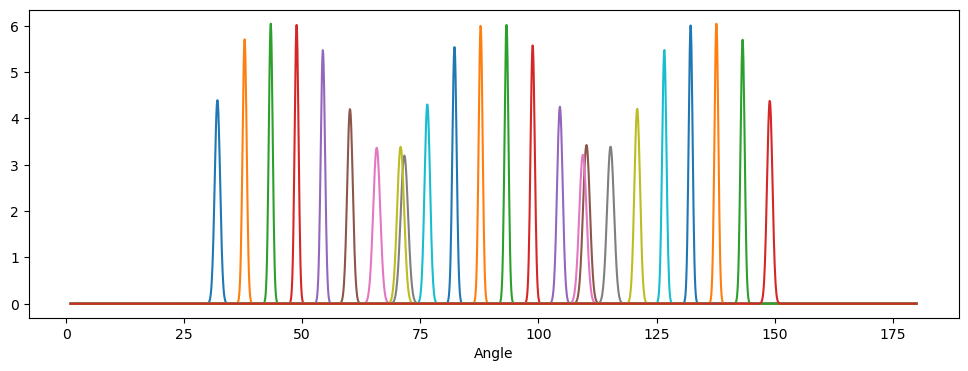

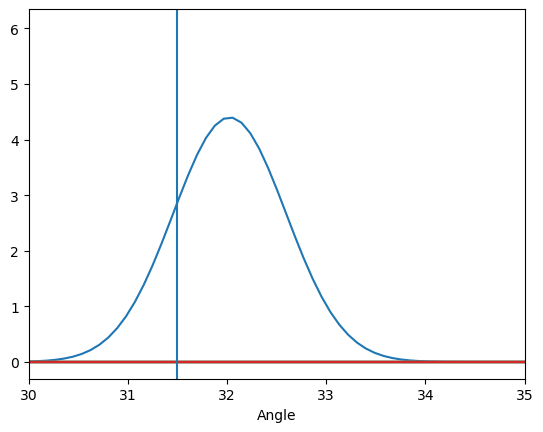

In [31]:
theta = np.linspace(1,180,2001)
# theta = np.repeat(np.reshape(theta,[-1,1]),24,axis=1)

fig, ax = plt.subplots(figsize=(12,4))

# expected response function of each detector
alpha=1
sigma = widths_ssd*.2

W_thetas = []
for i in range(24):
    W_theta = alpha*(1/sigma[i]*np.sqrt(2*np.pi))*np.e**(-0.5*((theta-(angles_ssd[i]+0.5))/sigma[i])**2)
    W_thetas.append(W_theta)
    plt.plot(theta,W_theta)

plt.xlabel('Angle')
plt.show()

for i in range(24):
    W_theta = alpha*(1/sigma[i]*np.sqrt(2*np.pi))*np.e**(-0.5*((theta-(angles_ssd[i]+0.5))/sigma[i])**2)
    plt.plot(theta,W_theta)

plt.axvline(31.5)

plt.xlim(30,35)
plt.xlabel('Angle')
plt.show()

In [57]:
import importlib
importlib.reload(hrzn_utils)


clear_water_blank = np.array([7,7, 2,4,6,8,10,12, 1,5,7,9,11,13,16,18,23,27,29,32,34,38,40,42,1,3,3,3,7,7,11,11,13,15,17]) - 1
bead_ids = np.array([17,18, 3,5,7,9,11,13, 4,6,8,10,12,15,17,19,26,28,30,33,37,39,41,43,2,4,5,6,8,9,10, 12, 14, 16, 18]) - 1
bead_diams = [0.031, 0.06,50,20,10,0.7,0.7,0.51,.100, .303, .510, .702, .903, 2.020,10.020, 20.060,.100, .303, .510, .702, .903, 2.020,10.020, 20.060,.903, .903, .903,.903,.903,.903, .702, .702,.702,.702,.702]
bead_stds = np.array([0.001, 0.002,1.1,.12,.06,0.006,0.006,0.006,0.003,0.005,0.006,0.007,0.006,0.012,.06,.12,0.003,0.005,0.006,0.007,0.006,0.012,.06,.12,0.006,0.006,0.006,0.006,0.006,0.006,0.007,0.007,0.007,0.007,0.007])

A = 'data/ferps_ooclass_2023/'
lenA = 2;

B = 'data/labcal_080623/'
lenB = 6;

C='data/Calibrations 2/'
lenC = 8;

D='data/Calibrations 2/'
lenD = 8;

E = 'data/dilution_280923/'
lenE = 11;

csv_list = []
pattern = '*.csv'
for i in range(36):
    if i < lenA:
        directory = A
        csv_files = glob.glob(directory + pattern)
        csv_list.append(csv_files[bead_ids[i]])
        csv_list.append(csv_files[clear_water_blank[i]])
    elif i < lenA+lenB:
        directory = B
        csv_files = glob.glob(directory + pattern)
        csv_list.append(csv_files[bead_ids[i]])
        csv_list.append(csv_files[clear_water_blank[i]])
    elif i < lenA+lenB+lenC:
        directory = C
        csv_files = glob.glob(directory + pattern)
        csv_list.append(csv_files[bead_ids[i]])
        csv_list.append(csv_files[clear_water_blank[i]])
    elif i < lenA+lenB+lenC+lenD:
        directory = D
        csv_files = glob.glob(directory + pattern)
        csv_list.append(csv_files[bead_ids[i]])
        csv_list.append(csv_files[clear_water_blank[i]])
    elif i < lenA+lenB+lenC+lenD+lenE:
        directory = E
        csv_files = glob.glob(directory + pattern)
        csv_list.append(csv_files[bead_ids[i]])
        csv_list.append(csv_files[clear_water_blank[i]])

csv_list = csv_list[8*2:24*2] + csv_list[2*2:8*2] + csv_list[:2*2] + csv_list[24*2:]
bead_diams = bead_diams[8:24] + bead_diams[2:8] + bead_diams[:2] + bead_diams[24:]



# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_52_25.csv'] # this is the highly filtered milliQ blank
transmission_factor=0


# processed = hrzn_utils.full_process(csv_list, using_fscat=False, apply_atten_corr=True, subtract_zscat=True, empirical_corr_factor=True, specific_zscat_file=specific_zscat_file)
processed, monte_carlo_results_0, monte_carlo_results_90, cscatFwd_monte_carlo = hrzn_utils.full_process(csv_list, using_fscat=False, apply_atten_corr=True, subtract_zscat=True, empirical_corr_factor=True,  transmission_factor=transmission_factor)
processed['utc_dt'] = processed.datetime
processed = processed.set_index('utc_dt')
processed = processed.sort_index(ascending=True)
# horizon_df = horizon_df.iloc[1:]


fn = 'mie_beamc.mat'
mat = scipy.io.loadmat(fn)
mie_beamc = mat['mie_beamc']
mie_beamc.shape
# mie_beamc = mie_beamc[0]
# mie_beamc = np.concatenate([mie_beamc[8:24], mie_beamc[2:8], mie_beamc[:2], mie_beamc[24:]])

fn = 'full_mie_meas_all.mat'
mat = scipy.io.loadmat(fn)
full_mie_meas = mat['full_mie_meas']
full_mie_meas.shape

full_mie_meas = full_mie_meas / mie_beamc.reshape(2,-1,1)

mie_all_runs = [full_mie_meas[:,8:24],full_mie_meas[:,2:8], full_mie_meas[:,:2], full_mie_meas[:,24:]]

mie_all_runs = []
for i in range(8,24):
    mie_all_runs.append(full_mie_meas[:,i])
for i in range(2,8):
    mie_all_runs.append(full_mie_meas[:,i])
for i in range(0,2):
    mie_all_runs.append(full_mie_meas[:,i])
for i in range(24,35):
    mie_all_runs.append(full_mie_meas[:,i])
mie_all_runs = np.array(mie_all_runs)

mie_convolved0 = []
mie_convolved1 = []
for idx in range(len(mie_all_runs)):
    mie_convolved0.append((mie_all_runs[idx,0]* np.array(W_thetas)).sum(axis=1)/70.2)
    mie_convolved1.append((mie_all_runs[idx,1]* np.array(W_thetas)).sum(axis=1)/70.2)

mie_convolved0 = np.array(mie_convolved0)
mie_convolved1 = np.array(mie_convolved1)

mie_perp_modeled = mie_convolved0+mie_convolved1*0.025
mie_para_modeled = mie_convolved1+mie_convolved0*0.025

mie_perp_raw = mie_all_runs[:,0]
mie_para_raw = mie_all_runs[:,1]

we have: 986 measurements to process
** Data rows removed due to light-dark error **
   173 row(s) removed
** Data rows removed due to saturation **
   scatSsdRawLight, 289 row(s) removed
   scatSsdRawDark, 169 row(s) removed
0.8136158140489629
0.6745363778531563
0.8689201159746298
0.8332507821078854
0.7927538726227271
0.7729562593661448
0.7524802821642004
0.7374938058432909
0.7182101317832295
0.7095392469817055
0.5681763380155894
0.5708455705832893
0.12701993820753643
0.1242985148419199
0.0661839737413008
0.06520581206656839
0.8812901335322971
0.7531660498301386
0.8374835094734319
0.8027969316462351
0.7966981440039208
0.7770583953305648
0.7593241082050426
0.7451065811266695
0.7463601649962066
0.7336641924914182
0.5549181707402538
0.5592709218983793
0.2
0.2
0.26303816067797736
0.2485687331000227
0.2
0.2
0.2
0.2
0.2
0.2
0.7782085580139564
0.7737485964929874
0.7880885452437849
0.7829485892344925
0.7962319217343468
0.8182921988440391
0.2
0.2
0.9468550862852236
0.7021246143392057
0.5746088

In [92]:
samples = [
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    'student',
    '200nm beads D1 (no paddles)',
    '200nm beads D2 (no paddles)',
    '200nm beads D3 (no paddles)',
    '200nm beads D4 (no paddles)',
    '200nm beads D4 (paddles back on)',
    '200nm beads D1',
    '200nm beads D2',
    '200nm beads D3',
    '200nm beads D4',
    '2um beads D1',
    '2um beads D2',
    '2um beads D3',
    '2um beads D4',
    'FSW DRE - this looks like the 1um beads',
    'TSW DRE',
    'TSW DRE',
    'Pav2 D1',
    'Pav2 D2',
    'T-Iso D1',
    'T-Iso D2',
    'CM D1',
    'CM D2',
    'CM D3',
    'Tet D1',
    'Tet D2',
    '3G surface (offshore)',
    '4C surface (closer to shore)',
    '4C deep (closer to shore 10m depth)',
    '1K surface (kennebec)',
    '1K surface (kennebec diluted)',
    '60nm beads D1',
    '60nm beads D2',
    '60nm beads D3',
    '60nm beads D4',
    '700nm beads D1',
    '700nm beads D2',
    '700nm beads D3',
    '700nm beads D4',
]

In [128]:
import importlib
importlib.reload(hrzn_utils)

# Get a list of all CSV files matching the pattern

# directory = 'data/EToptics/'
# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_52_25.csv'] # clean milliq blank
# specific_zscat_file = ['data/EToptics/2025-04-11_19_25_26.csv'] # P Stutz 4/8 Filtrate
# specific_zscat_file = ['data/EToptics/2025-04-11_19_47_18.csv'] # P Stutz "oldest" Filtrate


# directory = 'data/nd_filter_090126/no_filter/'
# directory = 'data/etoptics_120126/si_nanoparticles/'

directory = 'data/lisst_intercal/'
# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_17_23.csv'] # milliQ
# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_52_25.csv'] # this is the highly filtered milliQ blank


# specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_52_25.csv'] # this is the highly filtered milliQ blank
specific_zscat_file = ['data/lisst_intercal/2025-06-13_11_17_23.csv'] # this is the highly filtered seawater

transmission_factor = 1
nnf_factor = 0.28

pattern = '*.csv'
csv_files = glob.glob(directory + pattern)


processed, monte_carlo_results_0, monte_carlo_results_90, cscatFwd_monte_carlo = hrzn_utils.full_process(csv_files, using_fscat=False, 
    apply_atten_corr=True, subtract_zscat=True, empirical_corr_factor=True, specific_zscat_file=specific_zscat_file, transmission_factor=transmission_factor, nnf_factor=nnf_factor)

we have: 1418 measurements to process
** Data rows removed due to light-dark error **
   2 row(s) removed
** Data rows removed due to saturation **
   scatSsdRawLight, 92 row(s) removed
   scatSsdRawDark, 2 row(s) removed
we have: 12 measurements to process
** Data rows removed due to light-dark error **
   0 row(s) removed
** Data rows removed due to saturation **
   scatSsdRawLight, 0 row(s) removed
   scatSsdRawDark, 0 row(s) removed
2025-06-13 11:19:02.999999913
0.13719427158611674
0.13050729456670174
2025-06-13 11:19:02.999999913
0.14026351719179386
0.13357853888752613
2025-06-13 11:19:02.999999913
0.1370657743084721
0.13123234352401636
2025-06-13 11:19:02.999999913
0.13757567237936874
0.1317605900622919
2025-06-13 11:19:02.999999913
0.1371362135149169
0.13132097176180002
2025-06-13 11:19:02.999999913
0.28821166181501023
0.29156672177497267
2025-06-13 11:19:02.999999913
0.3651096294419932
0.3657185414134275
2025-06-13 11:19:02.999999913
0.09710514038482809
0.08501651194997162
2025

In [94]:
bead_samples = [.2,.2,.2,.2,.2,
               .2,.2,.2,.2,
               2,2,2,2,
               .06,.06,.06,.06,
               .7,.7,.7,.7,]

In [95]:
fn = 'full_mie_meas_oo25.mat'
mat = scipy.io.loadmat(fn)
full_mie_meas = mat['full_mie_meas']

fn = 'full_angles_mie.mat'
mat = scipy.io.loadmat(fn)
full_angles_mie = mat['full_angles_mie']

# this is directly from matlab
mie_beamc = [1.0172e-05,	0.004765,	0.8422,	6.550]

full_mie_meas[:,0] = full_mie_meas[:,0]/mie_beamc[0]
full_mie_meas[:,1] = full_mie_meas[:,1]/mie_beamc[1]
full_mie_meas[:,2] = full_mie_meas[:,2]/mie_beamc[2]
full_mie_meas[:,3] = full_mie_meas[:,3]/mie_beamc[3]

In [96]:
full_mie_meas.shape

(2, 4, 2001)

In [97]:
bead_samples = [.2,.2,.2,.2,.2,
               .2,.2,.2,.2,
               2,2,2,2,
               .06,.06,.06,.06,
               .7,.7,.7,.7,]

mie_all_runs = [full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],
               full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],full_mie_meas[:,1],
               full_mie_meas[:,3],full_mie_meas[:,3],full_mie_meas[:,3],full_mie_meas[:,3],
               full_mie_meas[:,0],full_mie_meas[:,0],full_mie_meas[:,0],full_mie_meas[:,0],
               full_mie_meas[:,2],full_mie_meas[:,2],full_mie_meas[:,2],full_mie_meas[:,2],]

mie_all_runs = np.array(mie_all_runs)

In [98]:
mie_convolved0 = []
mie_convolved1 = []
for idx in range(len(mie_all_runs)):
    mie_convolved0.append((mie_all_runs[idx,0]* np.array(W_thetas)).sum(axis=1)/70.2)
    mie_convolved1.append((mie_all_runs[idx,1]* np.array(W_thetas)).sum(axis=1)/70.2)

mie_convolved0 = np.array(mie_convolved0)
mie_convolved1 = np.array(mie_convolved1)

mie_perp_raw = mie_all_runs[:,0]
mie_para_raw = mie_all_runs[:,1]

In [99]:
mie_perp_modeled = mie_convolved0+mie_convolved1*0.025
mie_para_modeled = mie_convolved1+mie_convolved0*0.025

In [67]:
fn = 'full_angles_mie.mat'
mat = scipy.io.loadmat(fn)
full_angles_mie = mat['full_angles_mie']

# Now Begin

In [118]:
plt.rcParams.update({'font.size': 13})

In [119]:
dcal0pol = pd.read_csv('Hrzn_dcal_0DegPol.asc',header=None, delimiter='\t').values[0]
dcal90pol = pd.read_csv('Hrzn_dcal_90DegPol.asc',header=None, delimiter=',').values[0]

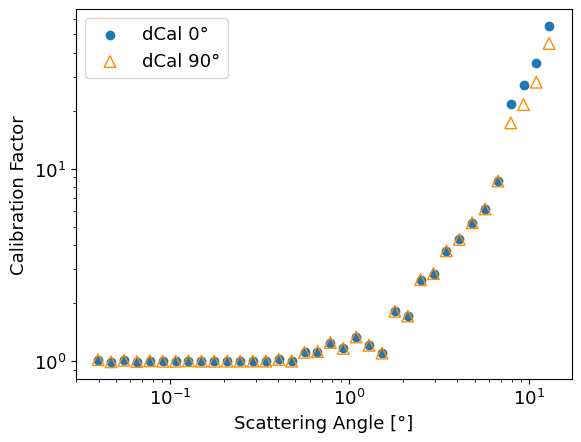

In [120]:
plt.scatter(angles_fwd,dcal0pol,label='dCal 0°')
plt.scatter(angles_fwd,dcal90pol,edgecolor='darkorange',facecolor='none',marker='^',s=70,label='dCal 90°')
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Scattering Angle [°]')
plt.ylabel('Calibration Factor')

plt.legend()

In [121]:
# these are the parameters for the forward scattering
rho = 1.18
theta0air = (0.102/120)

edge_angles = theta0air*rho**np.arange(0,37)
edge_angles = np.arcsin(np.sin(edge_angles)/1.33)

In [122]:
# find solid angle
dOmega=np.cos(edge_angles[0:36])-np.cos(edge_angles[1:37])

Text(0, 0.5, 'Solid Angle [sr]')

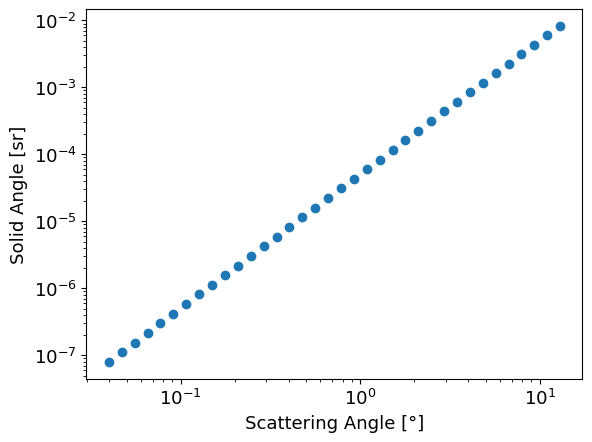

In [123]:
plt.scatter(angles_fwd,dOmega)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Scattering Angle [°]')
plt.ylabel('Solid Angle [sr]')

In [124]:
CBcycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

20.06
0.22765539253706302


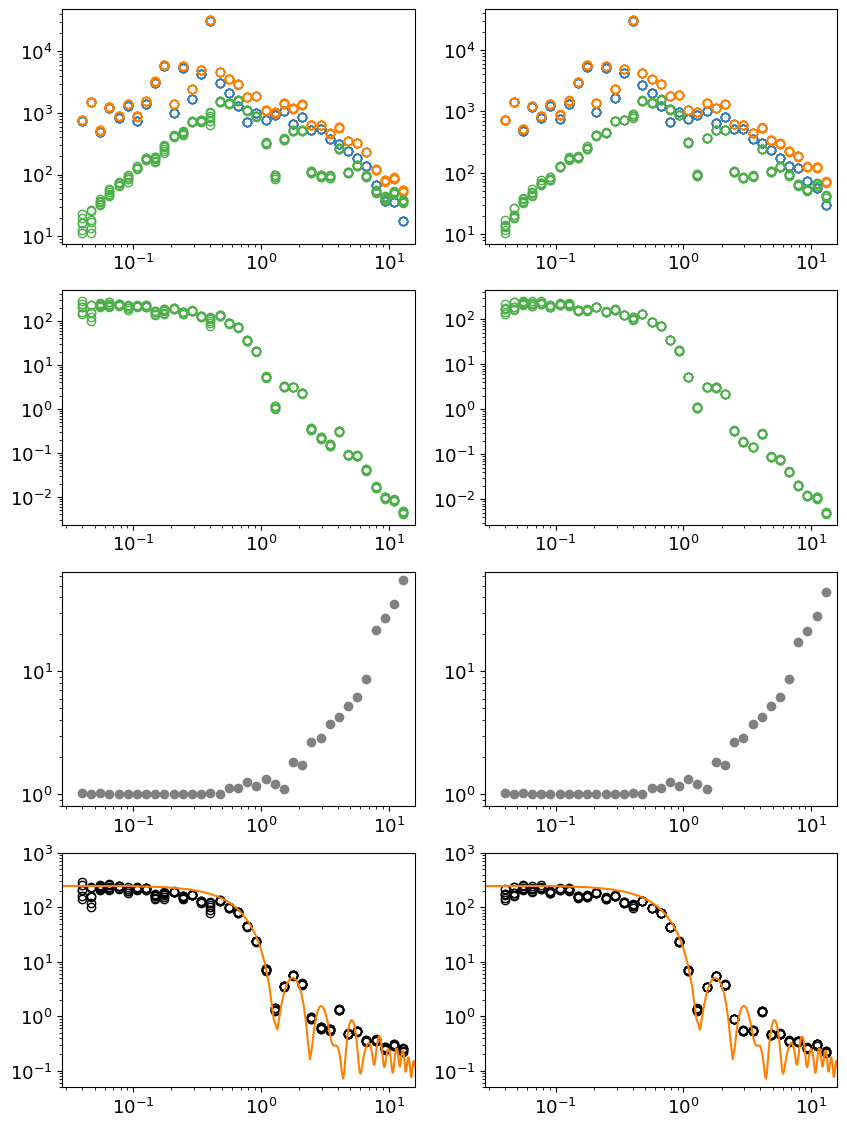

In [184]:
count = 0
mie_count = 0

for idx, sid in enumerate(processed.sample_id.unique()):
    samp_df = processed[processed.sample_id == sid]
    # print(samp_df.beamc)


    if idx not in [15]:
    # if idx not in [23]: # 60nm beads for comparison
        count +=1
        mie_count +=1
        continue

    print(bead_diams[idx])

    beamc_median = np.median(samp_df.beamc)
    print(beamc_median)

    mie_perp = (mie_perp_raw[mie_count]+mie_para_raw[mie_count]*.03)*beamc_median
    mie_para = (mie_para_raw[mie_count]+mie_perp_raw[mie_count]*.03)*beamc_median

    mie_s11 = mie_perp + mie_para
    mie_s12 = mie_para - mie_perp

    fig, ax = plt.subplots(4,2,figsize=(10,14))

    for j, pol_angle in enumerate([0,90]):
        
        scatFwd = np.vstack(samp_df[samp_df.polarizationAngle==pol_angle].initial_scatFwd)
        zscatFwd_scaled = np.vstack(samp_df[samp_df.polarizationAngle==pol_angle].zscatFwd_scaled)
    
        # correct particle scatter for attenuation
        scatFwd = scatFwd / (samp_df[samp_df.polarizationAngle==pol_angle].tau.values.reshape(-1,1)) 

        
        ax[0,j].plot(angles_fwd,zscatFwd_scaled.T,c=CBcycle[0],marker='o',ls='none',markerfacecolor='none',label='zscat')
        ax[0,j].plot(angles_fwd,scatFwd.T,c=CBcycle[1],marker='o',ls='none',markerfacecolor='none',label='scat')
        
        
        # subtract background
        scatFwd = scatFwd - zscatFwd_scaled #* samp_pol[samp_df.polarizationAngle==pol_angle].LREF.median() / zscat_pol[samp_df.polarizationAngle==pol_angle].LREF.median() # correct background for changes in Lref between background and sample

        ax[0,j].plot(angles_fwd,scatFwd.T,c=CBcycle[2],marker='o',ls='none',markerfacecolor='none',label='cscat')
        ax[0,j].set_yscale('log')
        ax[0,j].set_xscale('log')

        # ax[0,0].legend()

        scatFwd = scatFwd / dOmega / 1000000

        ax[1,j].plot(angles_fwd,scatFwd.T,c=CBcycle[2],marker='o',ls='none',markerfacecolor='none',label='cscat')
        ax[1,j].set_yscale('log')
        ax[1,j].set_xscale('log')
        
        # select dcal with polariztion that matches sample
        dcal_pol = None
        if pol_angle == 0:
            dcal_pol = dcal0pol
        elif pol_angle == 90:
            dcal_pol = dcal90pol

        ax[2,j].set_xscale('log')
        ax[2,j].set_yscale('log')
        ax[2,j].set_ylim(0.8,65)

        ax[2,j].scatter(angles_fwd,dcal_pol,c='grey')
        # ax[1,j].scatter(angles_fwd,dcal90pol,edgecolor='darkorange',facecolor='none',marker='^',s=70,label='dCal 90°')
        
        # apply dcal
        cscatFwd = scatFwd * dcal_pol  
        # cscatFwd = scatFwd # don't apply dcal
        
        cscatFwd = cscatFwd
        ax[3,j].plot(angles_fwd,cscatFwd.T,marker='o',ls='none',c='k',markerfacecolor='none')
        ax[3,j].plot(full_angles_mie,mie_s11,c='#ff7f00')
        ax[3,j].set_ylim(0.05,1000)
        ax[3,j].set_yscale('log')
        ax[3,j].set_xscale('log')
        # cscatFwd = cscatFwd * (LREF_nominal/samp_pol.LREF.values).reshape(-1,1)

        ax[0,j].set_xlim(0.028,16)
        ax[1,j].set_xlim(0.028,16)
        ax[2,j].set_xlim(0.028,16)
        ax[3,j].set_xlim(0.028,16)

        # ax[1,j].set_xlabel('Scattering Angle [°]')
        # plt.ylabel('Solid Angle [sr]')
        
        # cscatFwd[scatFwd_tofilter<20] = np.nan
        # cscatFwd_mc_list.append(cscatFwd_mc)
    plt.savefig('figs/fwd_scatter_cal.png',dpi=300,transparent=True)
    plt.show()
    count += 1
    mie_count += 1